# Questao 3

Recuperacao do arquivo `handel.wav` com filtros FIR. O sistema adotado foi
uma cascata linear de fase com tres blocos:

- passa-altas FIR Blackman, `fc = 180 Hz`, ordem `M = 120`;
- rejeita-faixas FIR Blackman, `1850-2150 Hz`, ordem `M = 260`;
- passa-baixas FIR Blackman, `fc = 2400 Hz`, ordem `M = 100`.

A comparacao com a Aula Pratica 6 usa como referencia o sistema IIR
`PA 180 Hz + PB 1800 Hz` com `r = 0.70`, exatamente na mesma linha do
notebook `pratica_6/questao_5.ipynb`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    helper_path = candidate / 'pratica_7' / 'fir_utils.py'
    if helper_path.exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError('Nao foi possivel localizar pratica_7/fir_utils.py a partir do diretorio atual.')

PRACTICE_DIR = REPO_ROOT / 'pratica_7'
DATA_DIR = REPO_ROOT / 'data'
if str(PRACTICE_DIR) not in sys.path:
    sys.path.insert(0, str(PRACTICE_DIR))

from scipy.io import wavfile

from fir_utils import (
    align_linear_phase,
    ap6_reference_filter,
    apply_linear_phase_fir,
    apply_window,
    basic_highpass_iir,
    build_fir_cascade,
    compare_signals,
    display_rows,
    ideal_bandstop,
    ideal_highpass,
    ideal_lowpass,
    load_handel_audio,
    mse,
    plot_frequency_grid,
    plot_impulse_grid,
    plot_pole_zero_grid,
    plot_time_and_spectrum,
    quantize_coefficients,
    residual_power,
    restore_length_after_delay,
    snr_db,
)

fs_audio, x = load_handel_audio(DATA_DIR)
t = np.arange(len(x), dtype=float) / fs_audio

print(f'fs do arquivo: {fs_audio} Hz')
print(f'duracao: {len(x) / fs_audio:.2f} s')
print(f'amplitude minima/maxima: {x.min():.4f} / {x.max():.4f}')


fs do arquivo: 8192 Hz
duracao: 8.92 s
amplitude minima/maxima: -0.8000 / 0.8000


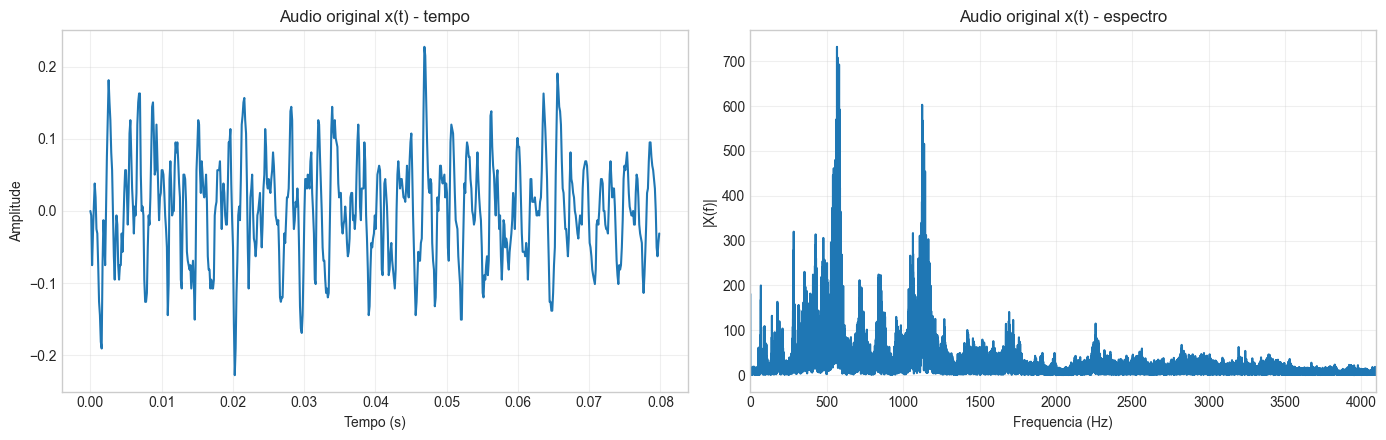

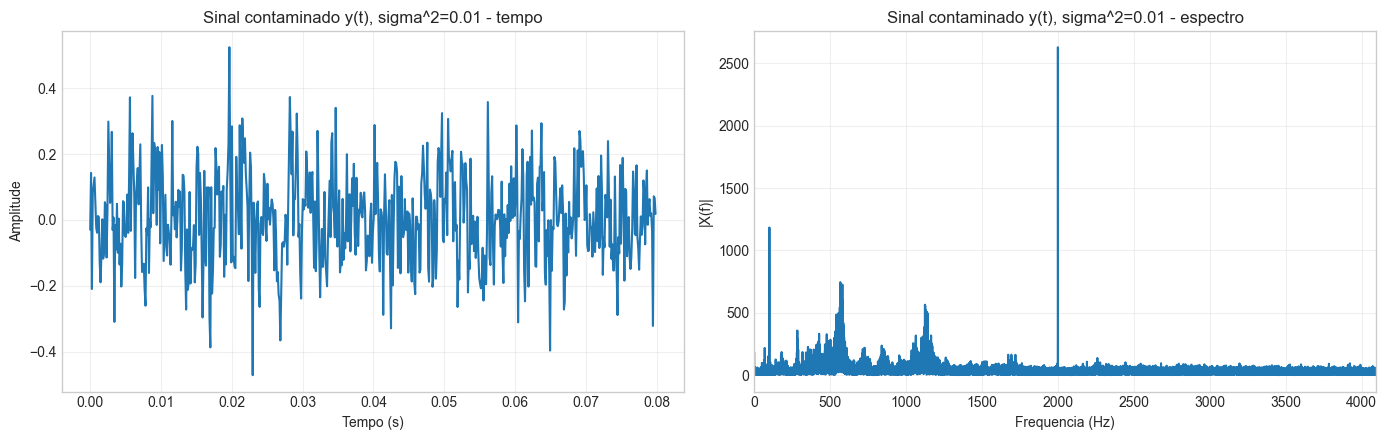

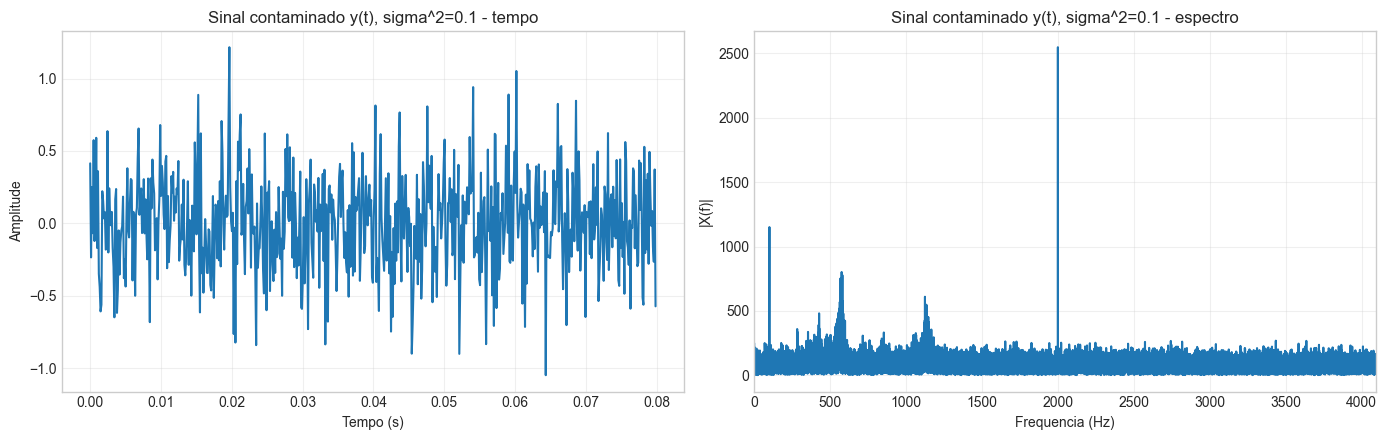

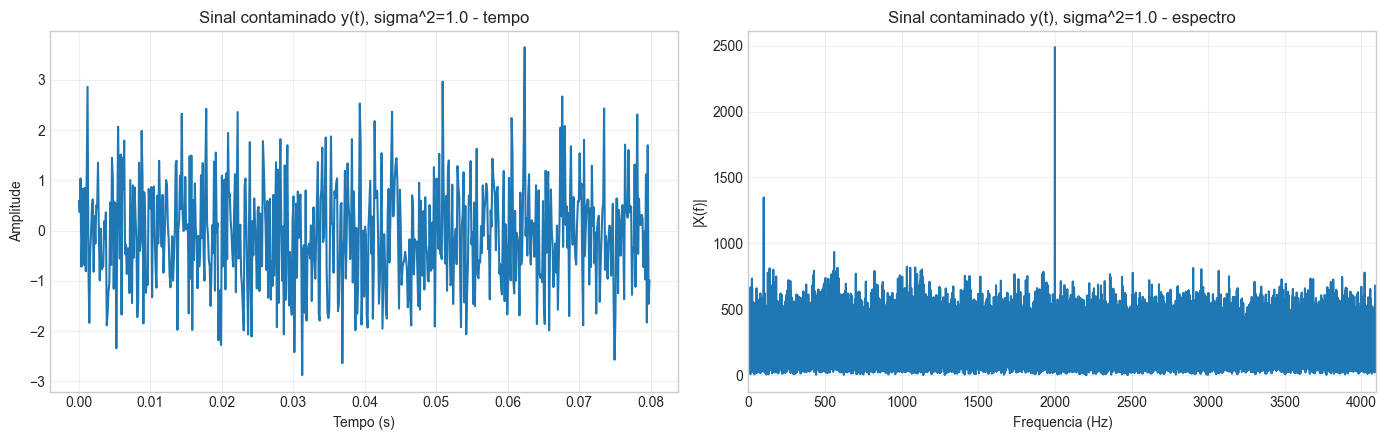

In [2]:
plot_time_and_spectrum(x, fs_audio, 'Audio original x(t)', seconds=0.08, xlim_freq=(0, fs_audio / 2))

SIGMA2_VALUES = [1e-2, 1e-1, 1.0]
rng = np.random.default_rng(2026)

tone_low = 0.05 * np.cos(200 * np.pi * t)
tone_high = 0.075 * np.sin(4000 * np.pi * t)

contaminated = {}
for sigma2 in SIGMA2_VALUES:
    noise = rng.normal(0.0, np.sqrt(sigma2), size=len(x))
    contaminated[sigma2] = x + tone_low + tone_high + noise

for sigma2, y in contaminated.items():
    plot_time_and_spectrum(
        y,
        fs_audio,
        f'Sinal contaminado y(t), sigma^2={sigma2}',
        seconds=0.08,
        xlim_freq=(0, fs_audio / 2),
    )


A estrutura FIR foi escolhida para atacar separadamente os tres problemas do
sinal contaminado:

- o tom de `100 Hz` e removido por um passa-altas com o mesmo corte da pratica 6;
- o tom em torno de `2000 Hz` e removido por um rejeita-faixas estreito, algo que a pratica 6 nao tinha como fazer com a mesma seletividade;
- um passa-baixas em `2400 Hz` reduz parte do ruido branco acima da regiao mais energetica do arquivo.

Como o sistema FIR e linear de fase, a comparacao quantitativa usa
compensacao explicita do atraso total.


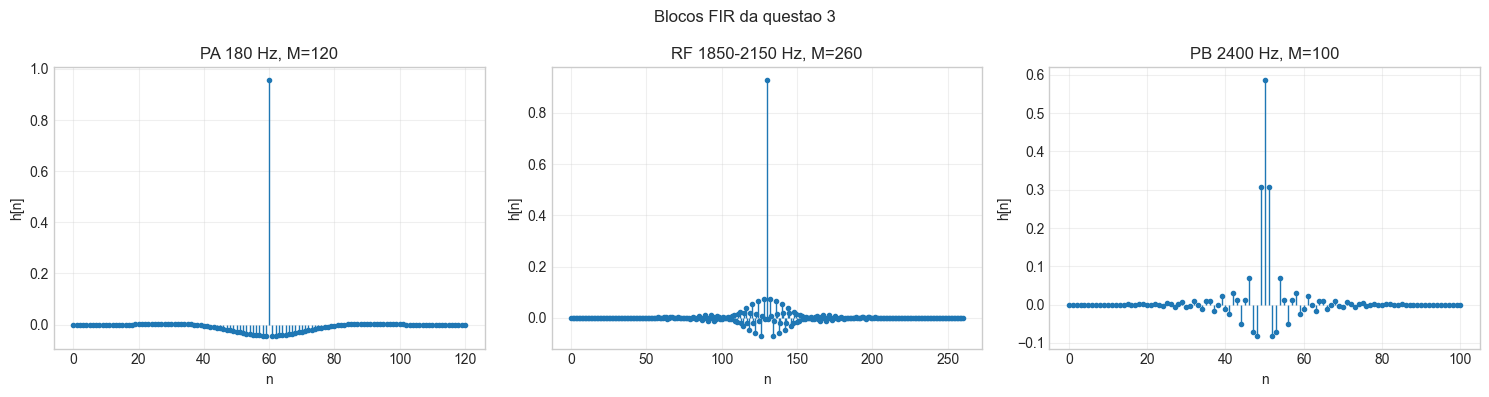

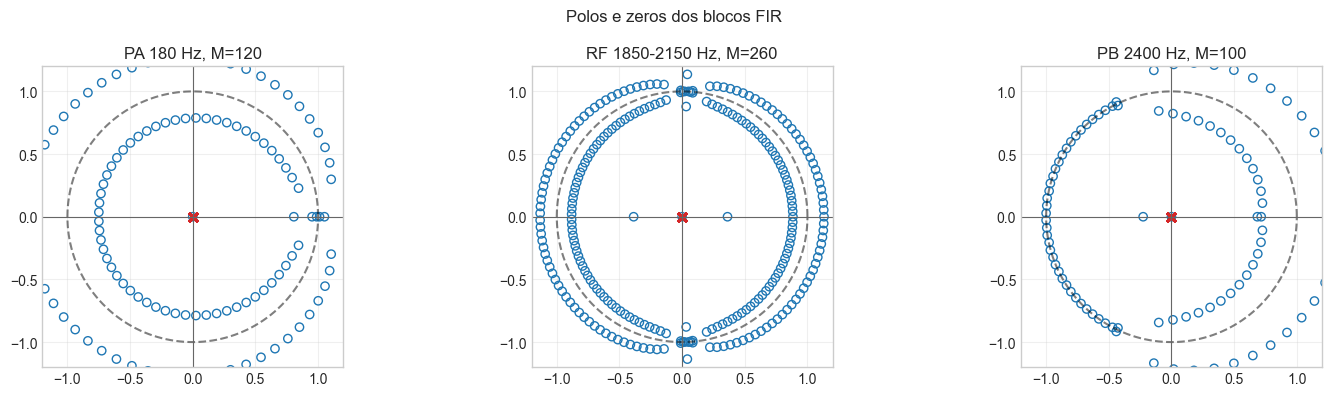

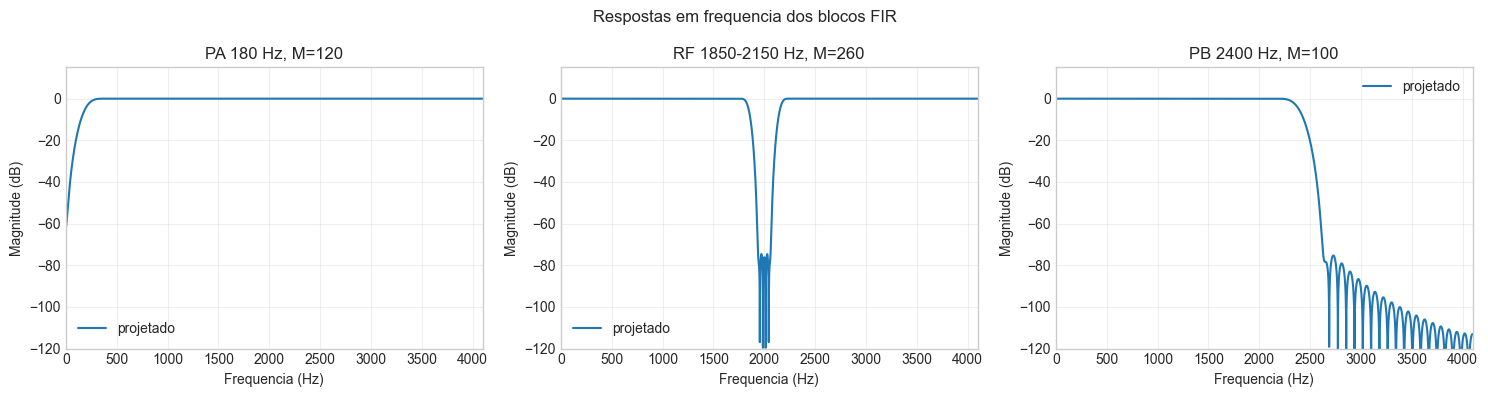

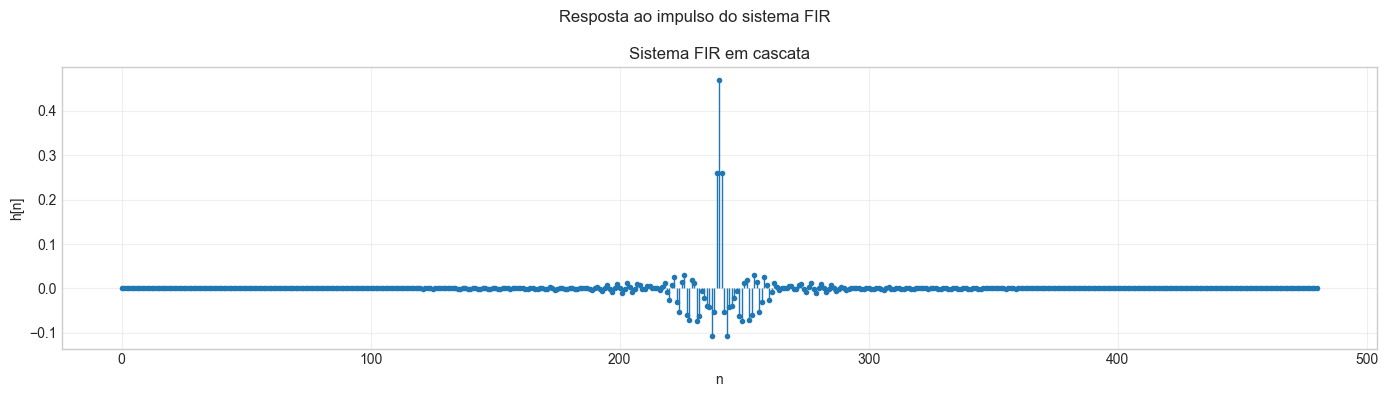

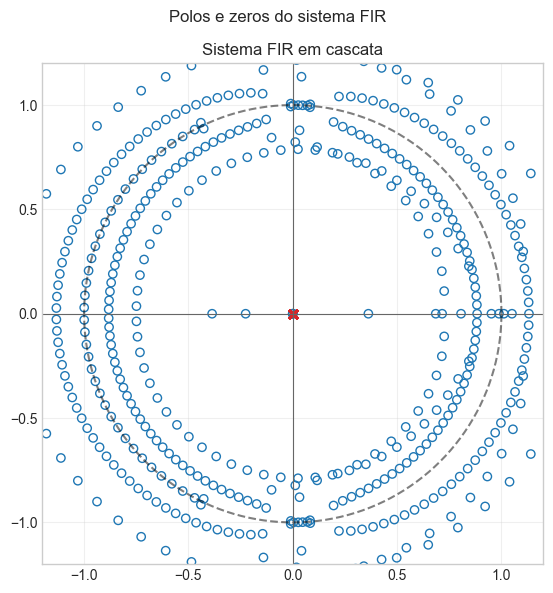

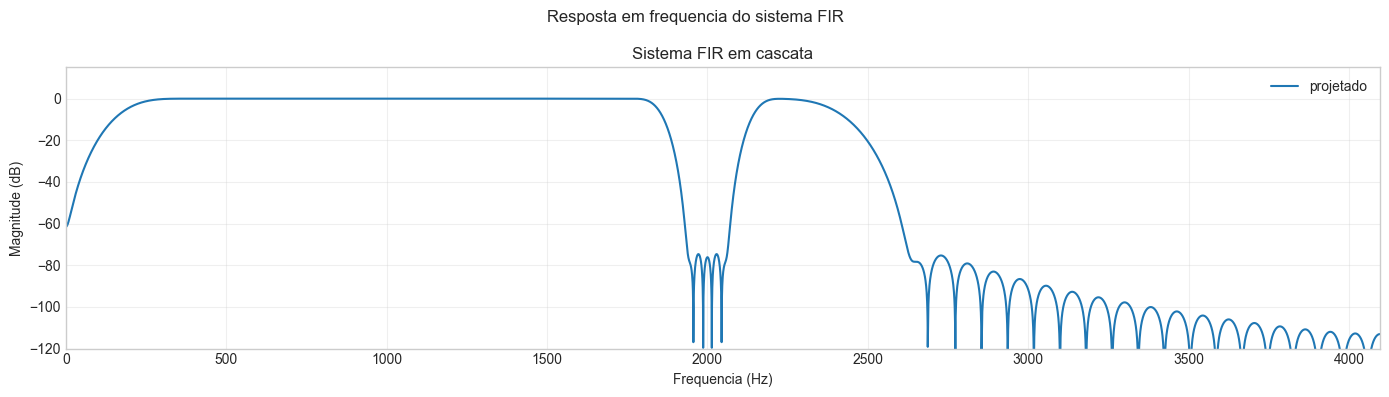

Atraso total do sistema FIR: 240 amostras (29.30 ms)


In [3]:
hp_fir = apply_window(ideal_highpass(180.0, 120, fs_audio), 'blackman', 120)
bs_fir = apply_window(ideal_bandstop(1850.0, 2150.0, 260, fs_audio), 'blackman', 260)
lp_fir = apply_window(ideal_lowpass(2400.0, 100, fs_audio), 'blackman', 100)

fir_blocks = {
    'PA 180 Hz, M=120': hp_fir,
    'RF 1850-2150 Hz, M=260': bs_fir,
    'PB 2400 Hz, M=100': lp_fir,
}

fir_system, fir_delay = build_fir_cascade(list(fir_blocks.values()))
b_iir, a_iir = ap6_reference_filter(fs_audio, r=0.70)

plot_impulse_grid(fir_blocks, 'Blocos FIR da questao 3', ncols=3, figsize=(15, 4))
plot_pole_zero_grid(fir_blocks, 'Polos e zeros dos blocos FIR', ncols=3, figsize=(15, 4))
plot_frequency_grid(
    fir_blocks,
    'Respostas em frequencia dos blocos FIR',
    ncols=3,
    figsize=(15, 4),
    fs_hz=fs_audio,
    xlim=(0, fs_audio / 2),
    as_db=True,
)

plot_impulse_grid({'Sistema FIR em cascata': fir_system}, 'Resposta ao impulso do sistema FIR', ncols=1, figsize=(14, 4))
plot_pole_zero_grid({'Sistema FIR em cascata': fir_system}, 'Polos e zeros do sistema FIR', ncols=1, figsize=(6, 6))
plot_frequency_grid(
    {'Sistema FIR em cascata': fir_system},
    'Resposta em frequencia do sistema FIR',
    ncols=1,
    figsize=(14, 4),
    fs_hz=fs_audio,
    xlim=(0, fs_audio / 2),
    as_db=True,
)

print(f'Atraso total do sistema FIR: {fir_delay} amostras ({1000 * fir_delay / fs_audio:.2f} ms)')


In [4]:
rows = []
fir_outputs = {}
iir_outputs = {}

for sigma2, y in contaminated.items():
    rows.append(
        {
            'sigma^2': sigma2,
            'Sistema': 'entrada',
            'SNR saida (dB)': snr_db(x, y),
            'MSE saida': mse(x, y),
            'Pot. ruido residual': residual_power(x, y),
        }
    )

    fir_raw = apply_linear_phase_fir(fir_system, y)
    x_ref_fir, x_hat_fir = align_linear_phase(x, fir_raw, fir_delay)
    fir_outputs[sigma2] = restore_length_after_delay(fir_raw, fir_delay)
    rows.append(
        {
            'sigma^2': sigma2,
            'Sistema': 'FIR AP7',
            'SNR saida (dB)': snr_db(x_ref_fir, x_hat_fir),
            'MSE saida': mse(x_ref_fir, x_hat_fir),
            'Pot. ruido residual': residual_power(x_ref_fir, x_hat_fir),
        }
    )

    iir_raw = signal.lfilter(b_iir, a_iir, y)
    iir_outputs[sigma2] = iir_raw
    rows.append(
        {
            'sigma^2': sigma2,
            'Sistema': 'IIR AP6',
            'SNR saida (dB)': snr_db(x, iir_raw),
            'MSE saida': mse(x, iir_raw),
            'Pot. ruido residual': residual_power(x, iir_raw),
        }
    )

display_rows(rows, float_digits=6)


sigma^2  | Sistema | SNR saida (dB) | MSE saida | Pot. ruido residual
---------+---------+----------------+-----------+--------------------
0.010000 | entrada | 4.393380       | 0.014003  | 0.014003           
0.010000 | FIR AP7 | 8.078308       | 0.006005  | 0.006005           
0.010000 | IIR AP6 | 0.052543       | 0.038045  | 0.038045           
0.100000 | entrada | -4.276012      | 0.103075  | 0.103075           
0.100000 | FIR AP7 | -0.733161      | 0.045670  | 0.045670           
0.100000 | IIR AP6 | -3.692657      | 0.090119  | 0.090119           
1.000000 | entrada | -14.172369     | 1.006439  | 1.006439           
1.000000 | FIR AP7 | -10.603605     | 0.443274  | 0.443274           
1.000000 | IIR AP6 | -12.063063     | 0.619237  | 0.619237           


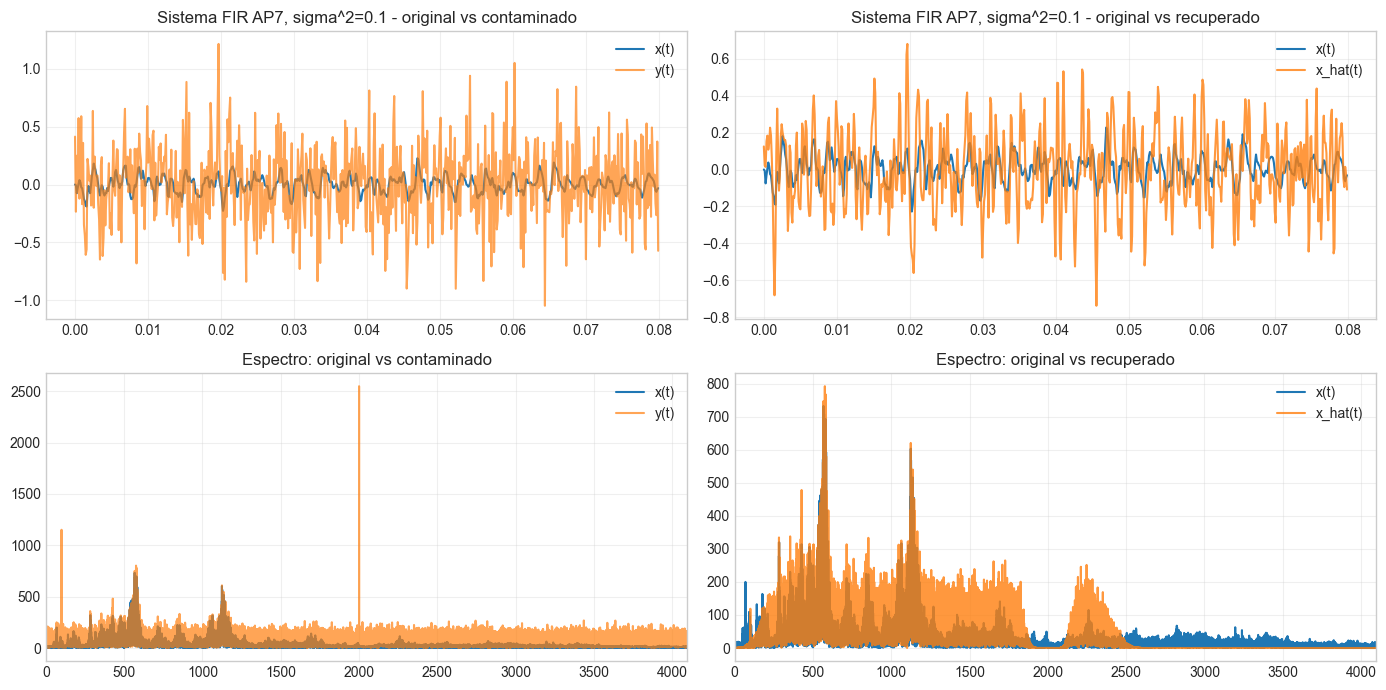

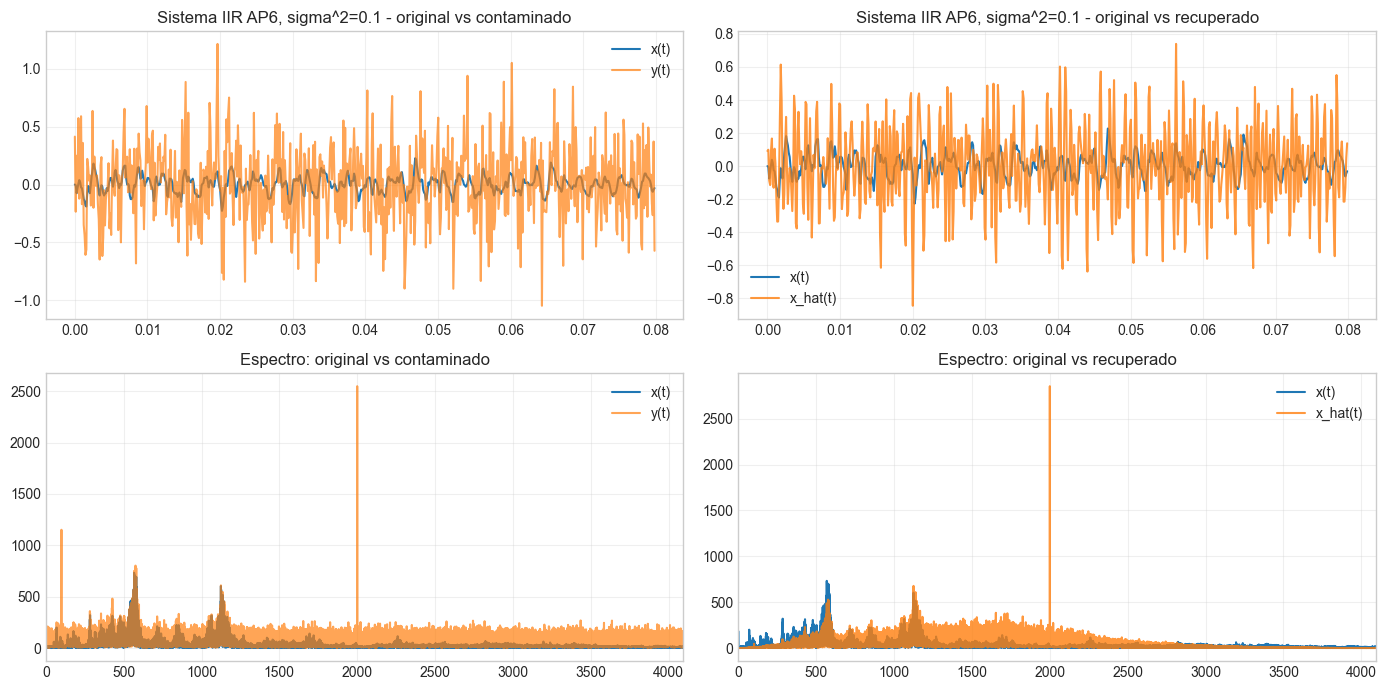

In [5]:
selected_sigma2 = 1e-1

compare_signals(
    x,
    contaminated[selected_sigma2],
    fir_outputs[selected_sigma2],
    fs_audio,
    'Sistema FIR AP7, sigma^2=0.1',
    seconds=0.08,
)

compare_signals(
    x,
    contaminated[selected_sigma2],
    iir_outputs[selected_sigma2],
    fs_audio,
    'Sistema IIR AP6, sigma^2=0.1',
    seconds=0.08,
)


**Leitura objetiva da comparacao**

- Em `sigma^2 = 10^-2` e `10^-1`, o FIR da pratica 7 costuma superar o IIR da pratica 6 em SNR e MSE porque remove o tom de `2000 Hz` de forma mais seletiva.
- Em `sigma^2 = 1`, o ruido branco domina boa parte da banda util, entao a vantagem do FIR diminui; ainda assim, a estrutura continua mais seletiva para as componentes tonais.
- A pratica 6 precisava usar um passa-baixas em `1800 Hz` para reduzir o tom alto, enquanto aqui a rejeicao em `1850-2150 Hz` preserva melhor o conteudo acima de `1800 Hz`.


In [6]:
try:
    from IPython.display import Audio, display

    print('Audio original:')
    display(Audio(x, rate=fs_audio))
    print('Audio contaminado, sigma^2 = 0.1:')
    display(Audio(contaminated[selected_sigma2], rate=fs_audio))
    print('Audio recuperado com FIR AP7:')
    display(Audio(fir_outputs[selected_sigma2], rate=fs_audio))
    print('Audio recuperado com IIR AP6:')
    display(Audio(iir_outputs[selected_sigma2], rate=fs_audio))
except Exception as exc:
    print(f'Reproducao de audio indisponivel neste ambiente: {exc}')


Audio original:


Audio contaminado, sigma^2 = 0.1:


Audio recuperado com FIR AP7:


Audio recuperado com IIR AP6:


**Avaliacao subjetiva esperada**

- O FIR da pratica 7 tende a soar menos abafado do que o IIR da pratica 6, porque o tom em `2000 Hz` e retirado com uma faixa de rejeicao mais estreita.
- A inteligibilidade melhora claramente para `sigma^2 = 10^-2` e `10^-1`, com menor coloracao na faixa media-alta.
- Para `sigma^2 = 1`, o ruido branco residual ainda e perceptivel, mas as duas interferencias tonais deixam de dominar a escuta.
- O atraso do FIR e fixo e facilmente compensavel; como a fase e aproximadamente linear, a forma de onda recuperada preserva melhor o alinhamento relativo entre componentes espectrais.


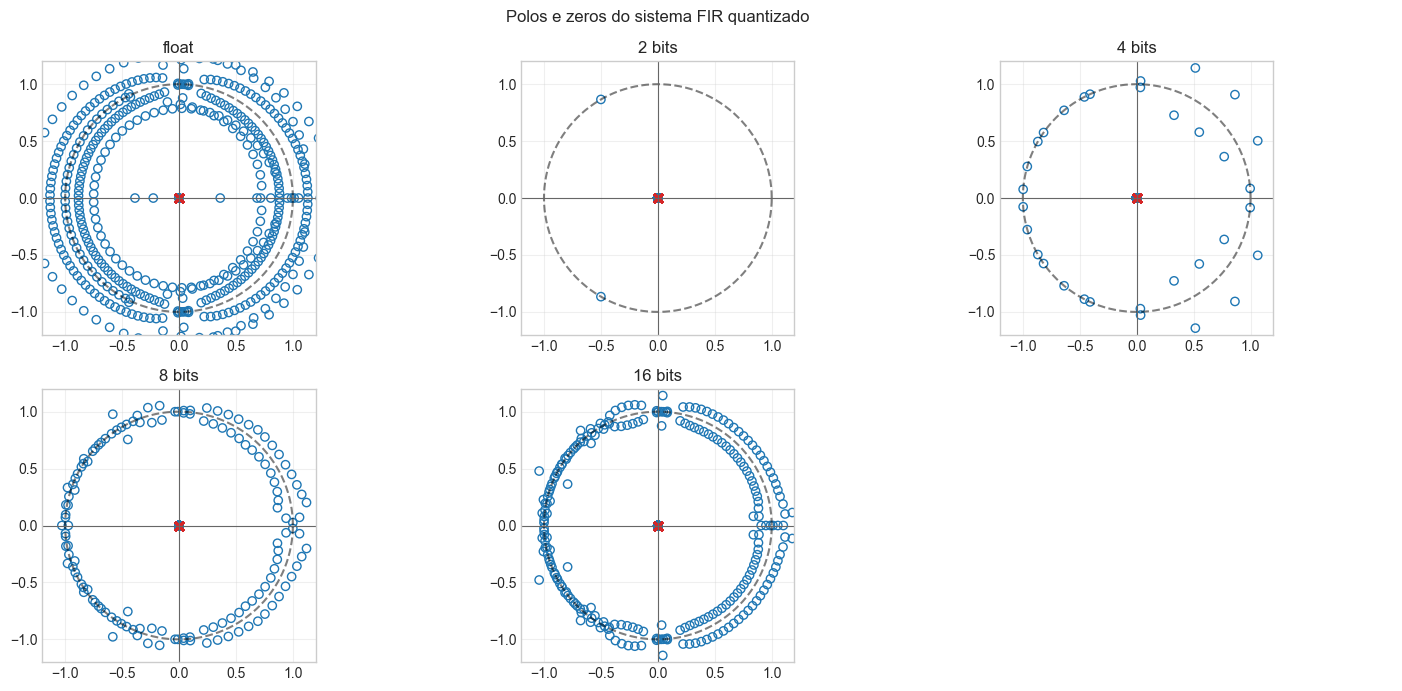

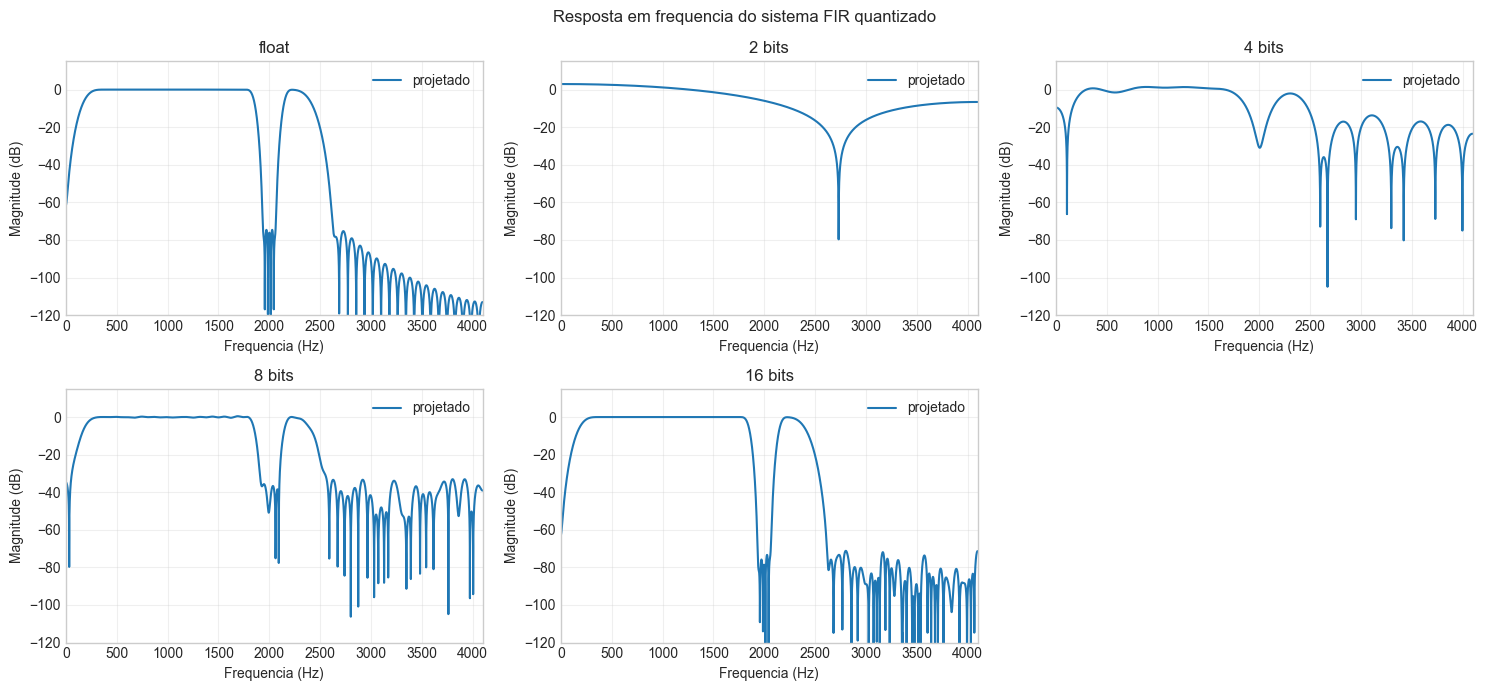

Filtro  | SNR saida (dB) | MSE saida | Pot. ruido residual | Coef. nao nulos
--------+----------------+-----------+---------------------+----------------
float   | -0.733161      | 0.045670  | 0.045670            | 481            
2 bits  | -2.772664      | 0.073043  | 0.073043            | 3              
4 bits  | -1.057316      | 0.049209  | 0.049209            | 21             
8 bits  | -0.721515      | 0.045547  | 0.045547            | 97             
16 bits | -0.733131      | 0.045669  | 0.045669            | 241            


In [7]:
BITS = [2, 4, 8, 16]
quantized_filters = {'float': fir_system}
for bits in BITS:
    quantized_filters[f'{bits} bits'] = quantize_coefficients(fir_system, bits)

plot_pole_zero_grid(quantized_filters, 'Polos e zeros do sistema FIR quantizado', ncols=3, figsize=(15, 7))
plot_frequency_grid(
    quantized_filters,
    'Resposta em frequencia do sistema FIR quantizado',
    ncols=3,
    figsize=(15, 7),
    fs_hz=fs_audio,
    xlim=(0, fs_audio / 2),
    as_db=True,
)

quant_rows = []
for label, coeffs in quantized_filters.items():
    filtered = apply_linear_phase_fir(coeffs, contaminated[selected_sigma2])
    x_ref, x_hat = align_linear_phase(x, filtered, fir_delay)
    quant_rows.append(
        {
            'Filtro': label,
            'SNR saida (dB)': snr_db(x_ref, x_hat),
            'MSE saida': mse(x_ref, x_hat),
            'Pot. ruido residual': residual_power(x_ref, x_hat),
            'Coef. nao nulos': int(np.count_nonzero(coeffs)),
        }
    )

display_rows(quant_rows, float_digits=6)


**Comentarios sobre a quantizacao**

- O caso de `2 bits` descaracteriza fortemente o filtro: poucos coeficientes sobrevivem e a resposta em frequencia perde seletividade.
- Em `4 bits`, a forma geral do filtro reaparece, mas a rejeicao ainda piora bastante e a qualidade do audio recuperado cai.
- Com `8 bits`, o comportamento ja fica bem proximo ao filtro em ponto flutuante para esta aplicacao.
- Em `16 bits`, a diferenca para o filtro original se torna praticamente desprezivel.
- A estabilidade nao muda com a quantizacao porque o sistema continua FIR; os polos permanecem na origem, enquanto o principal efeito da quantizacao aparece no deslocamento dos zeros.
